In [6]:
import tensorflow as tf
import sys

from tensorflow.keras.models import Sequential

In [7]:
# Optional CUDA/GPU check and memory growth setup
print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())

is_gpu_available = False
if hasattr(tf.test, 'is_gpu_available'):
    try:
        is_gpu_available = tf.test.is_gpu_available()
    except Exception:
        pass

gpus = []
if hasattr(tf.config, 'experimental') and hasattr(tf.config.experimental, 'list_physical_devices'):
    try:
        gpus = tf.config.experimental.list_physical_devices('GPU')
    except Exception:
        pass

print("GPU available:", is_gpu_available)
print("Physical GPU devices:", len(gpus))
for gpu in gpus:
    print(" -", gpu)

target_device = '/CPU:0'
if is_gpu_available or gpus:
    target_device = '/device:DML:0' if is_gpu_available else '/GPU:0'
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as e:
            print("Could not set memory growth on GPU:", e)
    print("Enabled memory growth on GPU(s). Using GPU path:", target_device)
else:
    print("No GPU found; training will run on CPU.")
    print("If you want GPU support on Windows, switch this notebook to the .venv_directml kernel and rerun.")

TensorFlow version: 2.15.0
Built with CUDA: False
GPU available: False
Physical GPU devices: 0
No GPU found; training will run on CPU.
If you want GPU support on Windows, switch this notebook to the .venv_directml kernel and rerun.


## GPU / DirectML Environment
This notebook will use the GPU path when a compatible GPU is detected.
If `GPUs available: 0` appears, switch the notebook kernel to the `.venv_directml` interpreter and rerun the notebook.

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_ds = train_datagen.flow_from_directory(
    "fer2013/versions/1/train",
    target_size=(96, 96),
    color_mode="rgb",
    batch_size=64,
    class_mode="categorical",
    shuffle=True,
    seed=42,
)

val_ds = val_datagen.flow_from_directory(
    "fer2013/versions/1/test",
    target_size=(96, 96),
    color_mode="rgb",
    batch_size=64,
    class_mode="categorical",
    shuffle=False,
    seed=42,
)

class_names = list(train_ds.class_indices.keys())
print("Classes:", class_names)
print("Train samples:", train_ds.samples)
print("Validation samples:", val_ds.samples)

use_class_weights = False
print("Using class weights:", use_class_weights)

Found 27473 images belonging to 7 classes.


KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

In [ ]:
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet',
)
base_model.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(lr=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        min_delta=0.0001,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "mobilenetv2_emotion_model.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
    ),
]

print("Training on device:", target_device)
with tf.device(target_device):
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=callbacks,
        verbose=1,
    )

model.save("/Users/sharanyamukherjee55/Downloads/somth/model_30epochs.h5", save_format="h5")
print("Saved!")

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 96, 96, 3)]          0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 48, 48, 32)           864       ['input_2[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 48, 48, 32)           128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 48, 48, 32)           0         ['bn_Conv1[0][0]']      

Training on device: /CPU:0
Epoch 1/100
430/430 [==============================] - ETA: 0s - loss: 1.6074 - accuracy: 0.4075
Epoch 1: val_accuracy improved from -inf to 0.42212, saving model to mobilenetv2_emotion_model.h5
430/430 [==============================] - 251s 577ms/step - loss: 1.6074 - accuracy: 0.4075 - val_loss: 1.7271 - val_accuracy: 0.4221 - lr: 0.0010
Epoch 2/100
430/430 [==============================] - ETA: 0s - loss: 1.2864 - accuracy: 0.5203
Epoch 2: val_accuracy did not improve from 0.42212
430/430 [==============================] - 267s 620ms/step - loss: 1.2864 - accuracy: 0.5203 - val_loss: 2.3101 - val_accuracy: 0.4021 - lr: 0.0010
Epoch 3/100
430/430 [==============================] - ETA: 0s - loss: 1.2002 - accuracy: 0.5588
Epoch 3: val_accuracy improved from 0.42212 to 0.48774, saving model to mobilenetv2_emotion_model.h5
430/430 [==============================] - 281s 653ms/step - loss: 1.2002 - accuracy: 0.5588 - val_loss: 1.7096 - val_accuracy: 0.4877 -

In [ ]:
import cv2
import numpy as np

# Webcam preprocessing helper functions
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def preprocess_webcam_face(frame, target_size=(48, 48)):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30),
    )
    if len(faces) == 0:
        return None, None

    x, y, w, h = faces[0]
    face_img = gray[y : y + h, x : x + w]
    face_img = cv2.resize(face_img, target_size)
    face_img = face_img.astype("float32") / 255.0
    face_img = np.expand_dims(face_img, axis=-1)
    face_img = np.expand_dims(face_img, axis=0)
    return face_img, (x, y, w, h)


def predict_emotion_from_webcam(frame, model, class_names):
    processed, bbox = preprocess_webcam_face(frame)
    if processed is None:
        return frame, None

    predictions = model.predict(processed, verbose=0)
    label = class_names[np.argmax(predictions)]
    confidence = float(np.max(predictions))

    x, y, w, h = bbox
    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(
        frame,
        f"{label}: {confidence:.2f}",
        (x, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2,
    )
    return frame, label

In [ ]:
import os
model_path = "mobilenetv2_emotion_model.h5"
if os.path.exists(model_path):
    best_model = tf.keras.models.load_model(model_path)
    print(f"Loaded checkpoint from {model_path}")
else:
    best_model = model
    print("Checkpoint not found; using the current model instance for evaluation.")

loss, accuracy = best_model.evaluate(val_ds, verbose=1)
print(f"Validation loss: {loss:.4f}, Validation accuracy: {accuracy:.4f}")

val_ds.reset()
predictions = best_model.predict(val_ds, steps=len(val_ds), verbose=1)

y_predict = np.argmax(predictions, axis=1)
y_true = val_ds.classes[:len(y_predict)]

Checkpoint not found; using the current model instance for evaluation.
113/113 [==============================] - 6s 49ms/step - loss: 1.3906 - acc: 0.6716
Validation loss: 1.3906, Validation accuracy: 0.6716
113/113 [==============================] - 8s 73ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
y_true

array([0, 0, 0, ..., 6, 6, 6])

In [ ]:
print(classification_report(y_true, y_predict, target_names=class_names))

              precision    recall  f1-score   support

       angry       0.58      0.58      0.58       958
     disgust       0.77      0.65      0.70       111
        fear       0.56      0.54      0.55      1024
       happy       0.85      0.86      0.86      1774
     neutral       0.61      0.65      0.63      1233
         sad       0.55      0.53      0.54      1247
    surprise       0.78      0.78      0.78       831

    accuracy                           0.67      7178
   macro avg       0.67      0.66      0.66      7178
weighted avg       0.67      0.67      0.67      7178



In [ ]:
cm=confusion_matrix(y_true,y_predict)

cm

array([[ 559,   10,  103,   47,   93,  125,   21],
       [  19,   72,    5,    3,    2,   10,    0],
       [ 115,    5,  549,   24,   82,  165,   84],
       [  40,    0,   25, 1533,   95,   47,   34],
       [  59,    4,   67,  101,  800,  181,   21],
       [ 155,    1,  146,   67,  202,  657,   19],
       [  20,    2,   91,   32,   28,    7,  651]], dtype=int64)

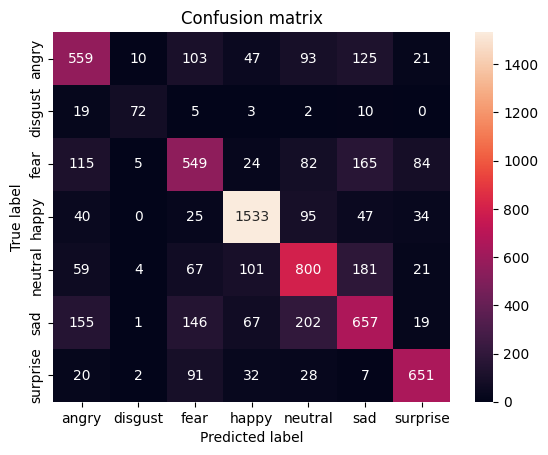

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()
